In [1]:
# Mount Google Drive to access the dataset stored in your drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Unzip the dataset from Google Drive into the Colab environment

!unzip /content/drive/MyDrive/braintumordataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/Training/glioma/Tr-gl_291.jpg  
  inflating: /content/Training/glioma/Tr-gl_292.jpg  
  inflating: /content/Training/glioma/Tr-gl_293.jpg  
  inflating: /content/Training/gl

In [3]:
# Import all required libraries for data processing, deep learning and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# Function to create dataframe containing image paths and corresponding labels

def make_dataset(path):

    image_paths = []
    image_labels = []

    # Loop through class folders
    for folder in os.listdir(path):

        folder_path = os.path.join(path, folder)

        for img in os.listdir(folder_path):

            image_paths.append(os.path.join(folder_path, img))
            image_labels.append(folder)

    # Create dataframe
    df = pd.DataFrame({
        "img_path": image_paths,
        "img_label": image_labels
    })

    return df

In [5]:
# Load training and testing datasets into dataframe format

training_data = make_dataset('/content/Training')
testing_data = make_dataset('/content/Testing')

display(training_data.head())
display(testing_data.head())

,img_path,img_label
0,/content/Training/meningioma/Tr-me_1226.jpg,meningioma
1,/content/Training/meningioma/Tr-me_480.jpg,meningioma
2,/content/Training/meningioma/Tr-aug-me_35.jpg,meningioma
3,/content/Training/meningioma/Tr-me_724.jpg,meningioma
4,/content/Training/meningioma/Tr-me_1012.jpg,meningioma


,img_path,img_label
0,/content/Testing/meningioma/Te-me_242.jpg,meningioma
1,/content/Testing/meningioma/Te-aug-me_33.jpg,meningioma
2,/content/Testing/meningioma/Te-me_257.jpg,meningioma
3,/content/Testing/meningioma/Te-me_256.jpg,meningioma
4,/content/Testing/meningioma/Te-me_174.jpg,meningioma


In [6]:
# Split the testing dataset into validation and final testing datasets

valid_df, test_df = train_test_split(
    testing_data,
    train_size=0.5,
    shuffle=True,
    random_state=42
)

print("Training Samples:", len(training_data))
print("Validation Samples:", len(valid_df))
print("Testing Samples:", len(test_df))

Training Samples: 5600
Validation Samples: 800
Testing Samples: 800


In [30]:
# Define image size and batch size

batch_size = 16
img_size = (224,224)

In [31]:
# ImageDataGenerator is used to preprocess and augment images during training

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [32]:
# Generators load images in batches during training

train_generator = train_gen.flow_from_dataframe(
    training_data,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

valid_generator = test_gen.flow_from_dataframe(
    valid_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_generator = test_gen.flow_from_dataframe(
    test_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


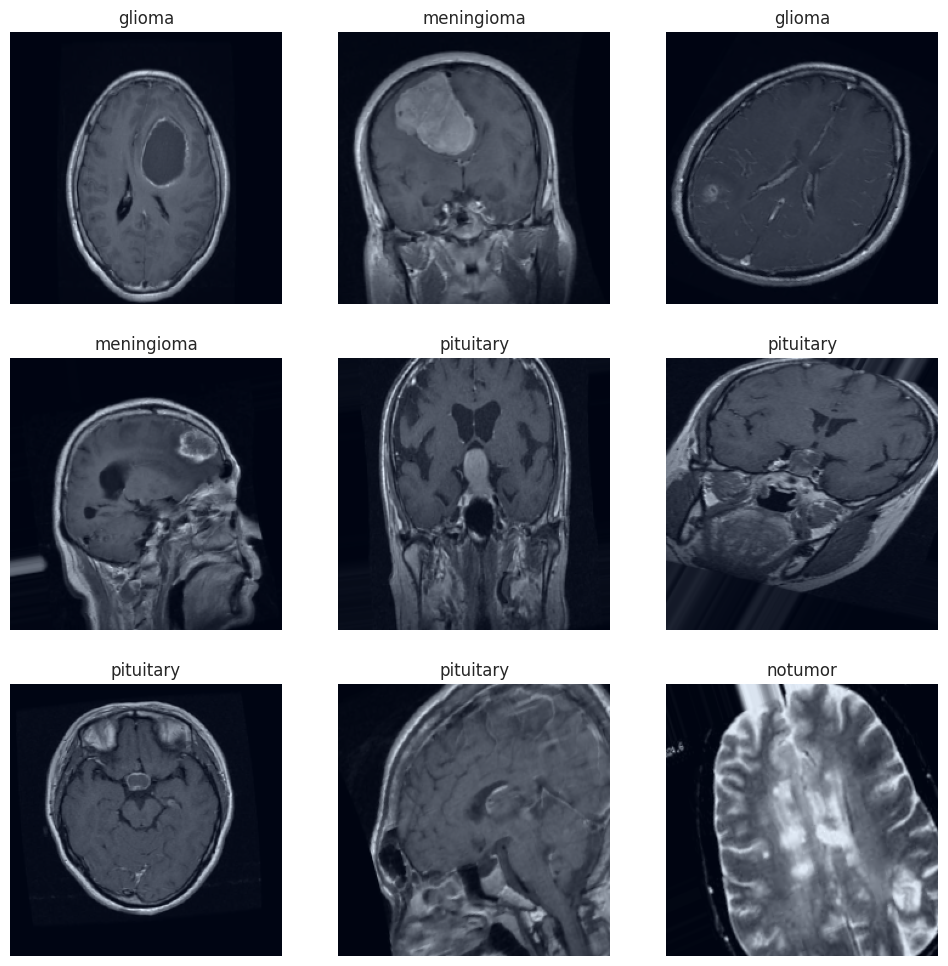

In [33]:
# Display some sample images from the dataset

# Get one batch of images from generator
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    # Reverse preprocessing so matplotlib can display properly
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    index = np.argmax(labels[i])
    plt.title(classes[index])

    plt.axis("off")

plt.show()

In [40]:
# Load pretrained DenseNet121 model without top classification layers

base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling="avg"
)

In [41]:
# Freeze all layers of DenseNet during first training phase

base_model.trainable = False

In [42]:
# Add custom classification layers on top of DenseNet

model = Sequential([
    base_model,

    BatchNormalization(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(4, activation="softmax")
])

In [43]:
# Compile the model with Adam optimizer

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,731,140 (29.49 MB)

 Trainable params: 691,588 (2.64 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [44]:
# Early stopping stops training if validation loss stops improving

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# Reduce learning rate when validation loss plateaus

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [45]:
print("Phase 1 : Transfer Learning")

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[early_stop, reduce_lr]
)

Phase 1 : Transfer Learning
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 142s 328ms/step - accuracy: 0.7614 - loss: 0.6224 - val_accuracy: 0.8213 - val_loss: 0.5183 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.8429 - loss: 0.4349 - val_accuracy: 0.8325 - val_loss: 0.4421 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.8616 - loss: 0.3842 - val_accuracy: 0.8438 - val_loss: 0.4275 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 88s 252ms/step - accuracy: 0.8720 - loss: 0.3533 - val_accuracy: 0.8612 - val_loss: 0.3964 - learning_rate: 0.0010
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 255ms/step - accuracy: 0.8763 - loss: 0.3302 - val_accuracy: 0.8450 - val_loss: 0.4400 - learning_rate: 0.0010
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 142s 254ms/step - accuracy: 0.8913 - loss: 0.3062 - val_accuracy: 0.8675 - val_loss: 0.4342 - learning_rate: 0.0010
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
print("Phase 2 : Full Fine-Tuning")

# Unfreeze entire DenseNet model

base_model.trainable = True

Phase 2 : Full Fine-Tuning


In [48]:
# Recompile with lower learning rate for fine tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
history_phase2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 127s 363ms/step - accuracy: 0.8909 - loss: 0.3192 - val_accuracy: 0.9112 - val_loss: 0.3420 - learning_rate: 1.0000e-04
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 112s 319ms/step - accuracy: 0.9325 - loss: 0.2094 - val_accuracy: 0.8863 - val_loss: 0.4664 - learning_rate: 1.0000e-04
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 307ms/step - accuracy: 0.9439 - loss: 0.1664 - val_accuracy: 0.9125 - val_loss: 0.4503 - learning_rate: 1.0000e-04
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 310ms/step - accuracy: 0.9677 - loss: 0.0921 - val_accuracy: 0.9400 - val_loss: 0.3251 - learning_rate: 2.0000e-05
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 308ms/step - accuracy: 0.9734 - loss: 0.0869 - val_accuracy: 0.9475 - val_loss: 0.2836 - learning_rate: 2.0000e-05
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 106s 303ms/step - accuracy: 0.9752 - loss: 0.0707 - val_accuracy: 0.9413 - val_loss: 0.3231 - learning_rate: 2.0000e-05
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 

In [51]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc*100)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9450 - loss: 0.2915
Test Accuracy: 94.49999928474426
Test Loss: 0.2915038764476776


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step


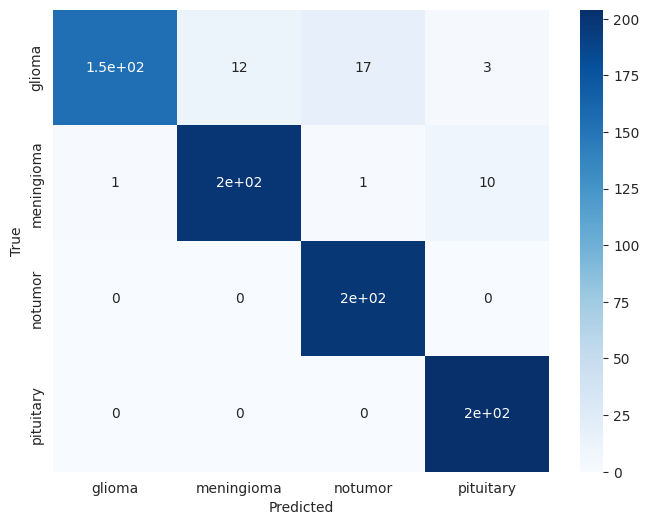

In [52]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [53]:
print(
classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

      glioma       0.99      0.83      0.90       186
  meningioma       0.94      0.94      0.94       212
     notumor       0.92      1.00      0.96       198
   pituitary       0.94      1.00      0.97       204

    accuracy                           0.94       800
   macro avg       0.95      0.94      0.94       800
weighted avg       0.95      0.94      0.94       800



In [54]:
model.save("brain_tumor_densenet121.keras")

print("Model saved successfully")

Model saved successfully


In [57]:
# Generate GradCAM heatmap for explainable AI

def gradcam(image_path):

    img = keras.preprocessing.image.load_img(image_path, target_size=(224,224))

    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.layers[0].output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)

    heatmap = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = np.maximum(heatmap,0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [58]:
# Simple segmentation using thresholding and contour detection

def tumor_segmentation(image_path):

    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray,(5,5),0)

    _, thresh = cv2.threshold(blur,45,255,cv2.THRESH_BINARY)

    contours,_ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        cv2.drawContours(img,[cnt],-1,(0,255,0),2)

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title("Tumor Segmentation")
    plt.axis("off")